## 📚  __Main imports__

Importing the required libraries and dependencies for data processing.

In [60]:
#LIBRERÍAS PRINCIPALES
import numpy             as np      
import pandas            as pd    
import matplotlib.pyplot as plt
import seaborn           as sns 
import scipy             as sp 
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder

## 🛠️ __Reading Data: CSV file - Transactional data__

In [ ]:
#RUTA.
path_alternative = "https://raw.githubusercontent.com/hector1994/-IIB415A-2-2026-1-1-1500C_BUSINESS-INTELLIGENCE/refs/heads/main/BI_Class_2_eda.csv"
#df  = pd.read_csv(path)                                                        #GENERANDO DATAFRAME.
df = pd.read_csv(path_alternative)                                              #GENERANDO DATAFRAME.

df.head()   #df.tail()                                            #VISUALIZAR LOS PRIMEROS/ÚLTIMOS N REGISTROS

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,Home,united states,1,347.837835,21.641612,3.171993,337.542782
3,5003,2024-01-01 03:00:00,32.0,Clothing,Canada,8,402.287483,50.009419,4.026504,3205.648837
4,5004,2024-01-01 04:00:00,60.0,Toys,U.S.A.,3,108.073620,66.607272,2.194199,327.554394


| ID | Feature | Technical Description | Data Classification |
| :--- | :--- | :--- | :--- |
| **0** | <font color="#7abaff">`Transaction_ID`</font> | Unique identifier for each sale record. Primary key for the dataset. | <font color="#7abaff">Identifier</font> |
| **1** | <font color="#7abaff">`Date`</font> | Timestamp of the transaction. Requires conversion to `datetime` objects. | <font color="#7abaff">Temporal</font> |
| **2** | <font color="#7abaff">`Customer_Age`</font> | Numerical age of the buyer. Useful for demographic segmentation. | <font color="#7abaff">Demographic</font> |
| **3** | <font color="#ffd43b">`Product_Category`</font> | Categorical label for item types (e.g., Clothing, Home, Toys). | <font color="#ffd43b">Categorical</font> |
| **4** | <font color="#ffd43b">`Country`</font> | Geographic origin of the order. Requires standardization (e.g., U.S.A vs united states). | <font color="#ffd43b">Geographic</font> |
| **5** | <font color="#ffd43b">`Units_Sold`</font> | Quantitative count of products purchased in a single transaction. | <font color="#ffd43b">Numeric (Discrete)</font> |
| **6** | <font color="#ff6b6b">`Unit_Price`</font> | Price per individual item. Base for revenue calculations. | <font color="#ff6b6b">Financial</font> |
| **7** | <font color="#ff6b6b">`Shipping_Cost`</font> | Operational cost for delivery. Impact on final profit margins. | <font color="#ff6b6b">Financial</font> |
| **8** | <font color="#ff6b6b">`Total_Revenue`</font> | Gross income from the sale (`Units_Sold` * `Unit_Price`). Target variable. | <font color="#ff6b6b">Financial (Target)</font> |
| **9** | <font color="#8ce99a">`Rating`</font> | Customer satisfaction score. Key metric for product performance. | <font color="#8ce99a">Quality Metric</font> |

## 🗺️ __Exploratoy Data Analysis (EDA)__

#### ✅ __Let's check the dataframe features__

In [62]:
#MÉTODO describe(): RESUMEN ESTADÍSTICO INSTANTANEO SOBRE LAS COLUMNAS NUMÉRICAS (INT, FLOAT) DEL DATAFRAME.
df.describe()

,Transaction_ID,Customer_Age,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
count,2550.000000,2424.000000,2550.000000,2550.000000,2550.000000,2475.000000,2550.000000
mean,6225.480392,49.094884,5.545882,315.166411,52.028912,3.049203,1411.328312
std,734.631632,17.877030,2.882295,702.822872,27.756064,1.000743,1153.869290
min,5000.000000,18.000000,1.000000,10.005701,5.114343,1.000000,-10.294671
25%,5587.250000,34.000000,3.000000,132.373066,27.511696,2.266439,448.038896
50%,6224.500000,49.000000,6.000000,258.960575,51.324563,3.032429,1086.333938
75%,6861.750000,65.000000,8.000000,379.875368,76.712596,3.835179,2105.937489
max,7499.000000,79.000000,10.000000,11478.781639,99.890259,5.000000,4992.820153


In [63]:
#MÉTODO info(): RESUMEN GENERAL DEL DATAFRAME - NOMBRE COLUMNA, CANTIDAD DE REGISTROS NO NULOS Y TIPO DE DATO.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    2550 non-null   int64  
 1   Date              2550 non-null   object 
 2   Customer_Age      2424 non-null   float64
 3   Product_Category  2550 non-null   object 
 4   Country           2550 non-null   object 
 5   Units_Sold        2550 non-null   int64  
 6   Unit_Price        2550 non-null   float64
 7   Shipping_Cost     2550 non-null   float64
 8   Rating            2475 non-null   float64
 9   Total_Revenue     2550 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 199.3+ KB


In [64]:
#columns - ATRIBUTO: LISTA DE LAS COLUMNAS DEL DATAFRAME.
df.columns

Index(['Transaction_ID', 'Date', 'Customer_Age', 'Product_Category', 'Country',
       'Units_Sold', 'Unit_Price', 'Shipping_Cost', 'Rating', 'Total_Revenue'],
      dtype='object')

In [65]:
#DATAFRAME shape - ATRIBUTO: ROWS - COLUMNS - DIMENSIONES DEL DATAFRAME.
df.shape

(2550, 10)

#### 🔢 __Let's apply some counting to our categorical features__

In [66]:
#SELECCIONAR UN SUBCONJUNTO > 1 DE COLUMNAS DEL DATAFRAME Y VISUALIZAR DICHAS COLUMNAS.
column_list = [ 'Date','Transaction_ID', 'Customer_Age', 'Product_Category'] #Columnas de interés
df[column_list]  

,Date,Transaction_ID,Customer_Age,Product_Category
0,2024-01-01 00:00:00,5000,56.0,Clothing
1,2024-01-01 01:00:00,5001,69.0,Clothing
2,2024-01-01 02:00:00,5002,46.0,Home
3,2024-01-01 03:00:00,5003,32.0,Clothing
4,2024-01-01 04:00:00,5004,60.0,Toys
...,...,...,...,...
2545,2024-01-02 21:00:00,5045,79.0,Electronic
2546,2024-01-02 22:00:00,5046,79.0,Clothing
2547,2024-01-02 23:00:00,5047,64.0,Home
2548,2024-01-03 00:00:00,5048,79.0,Clothing


In [67]:
#MÉTODO value_counts(): CONTEO DE REGISTROS ASOCIADOS A UNA VARIABLE CATEGÓRICA (NOMINAL-ORDINAL)
100*df['Country'].value_counts(normalize= True)

Country
UK               15.568627
Canada           14.862745
U.S.A.           13.372549
united states    12.823529
 USA             12.352941
usa              11.960784
France            9.568627
Germany           9.490196
Name: proportion, dtype: float64

In [68]:
#MÉTODO unique(): VALORES DISTINTOS EN COLUMNA CATEGÓRICA
df['Product_Category'].unique()

array(['Clothing', 'Home', 'Toys', ' Elect. ', 'Books', 'Electronic',
       'ELECTRONICS', 'electronics'], dtype=object)

In [69]:
#MÉTODO nunique(): CANTIDAD DE VALORES DISTINTOS EN UNA COLUMNA CATEGÓRICA.
df['Country'].nunique()

8

## 🧐 __Analyzing + Solving Data issues__

* __Nan Values__
* __Standarize categorical features__
* __Duplicated rows__


#### ❌<code>NaN</code> values. Fixing empty data

In [70]:
#Método insa() y sum(): NaN Summary: CONTAR VALORES FALTANTES POR CADA FEATURE DEL DATAFRAME (NUMÉRICOS Y CATEGÓRICOS)
df.isna().sum()

Transaction_ID        0
Date                  0
Customer_Age        126
Product_Category      0
Country               0
Units_Sold            0
Unit_Price            0
Shipping_Cost         0
Rating               75
Total_Revenue         0
dtype: int64

In [71]:
#ESTADÍSTICOS DE TENDECIA CENTRAL, DISPERSIÓN Y POSICIÓN (COLUMNAS NUMÉRICAS)
age_mean   = df['Customer_Age'].mean()
age_median = df['Customer_Age'].median()

In [72]:
age_median

49.0

In [73]:
#FILLNA: LUEGO DE DECIDIR COMO IMPUTAR (RELLENAR VALORES FALTANTES), APLICAR PROCESO DE RELLENADO.
df['Customer_Age'] = df['Customer_Age'].fillna(age_mean)

#### 👨‍🔧 Standarizing categorical feature

In [74]:
#Standarize Categorical Features
df['Country'].value_counts()

Country
UK               397
Canada           379
U.S.A.           341
united states    327
 USA             315
usa              305
France           244
Germany          242
Name: count, dtype: int64

In [75]:
#STANDARIZING: QUITAR ESPACIOS, REEMPLAZAR CARÁCTERES RAROS, DEFINIR FORMATO: MAYÚSCULAS, MINUSCULAS, NOMBRE PROPIO.
df['Country'] = df['Country'].str.strip() #ELIMINAR ESPACIOS EN BLANCO
df['Country'] = df['Country'].replace(".","") #QUITAR PUNTOS ---> FIND AND REPLACE
df['Country'] = df['Country'].str.upper()  #PASAR TODO A MAYUSCULA: UPPER(), LOWER(), TITLE()

In [76]:
df['Country'].value_counts()

Country
USA              620
UK               397
CANADA           379
U.S.A.           341
UNITED STATES    327
FRANCE           244
GERMANY          242
Name: count, dtype: int64

#### 🐈🐈 Deleting duplicates 

In [77]:
#DUPLICATED VALUES: TOTAL REGISTROS DUPLICADOS.
df.duplicated().sum()

50

In [78]:
#VER REGISTROS DUPLICADOS.
#keep = 'first': Muestra primer duplicado encontrado (por pares), es decir si un registro está dos veces, muestra solo el primero de este par.
#keep = 'last' : Muestra último duplicado encontrado (por pares), es decir si un registro está dos veces, muestra solo el último de este par.
#keep = 'False': Muestra ambos registros por pares, es decir, muestra literalmente los registros copiados, todos (preferible si queiren ver estos duplicados)
df[df.duplicated(keep = False)]

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,Home,UNITED STATES,1,347.837835,21.641612,3.171993,337.542782
3,5003,2024-01-01 03:00:00,32.0,Clothing,CANADA,8,402.287483,50.009419,4.026504,3205.648837
4,5004,2024-01-01 04:00:00,60.0,Toys,U.S.A.,3,108.073620,66.607272,2.194199,327.554394
...,...,...,...,...,...,...,...,...,...,...
2545,5045,2024-01-02 21:00:00,79.0,Electronic,UNITED STATES,8,107.775801,71.770828,2.221011,840.051185
2546,5046,2024-01-02 22:00:00,79.0,Clothing,U.S.A.,6,343.311839,63.334143,2.138245,2042.413167
2547,5047,2024-01-02 23:00:00,64.0,Home,CANADA,1,45.377220,53.474951,1.914145,72.851555
2548,5048,2024-01-03 00:00:00,79.0,Clothing,USA,5,25.019726,46.209518,2.195353,114.099654


In [79]:
#VER REGISTROS DUPLICADOS, PERO ORDENADOS USANDO df.sort_values(by = 'columna de ordenamiento', ascending = True/False) - ASÍ DE VEN JUNTOS ESTOS DUPLICADOS, PERMITE VERLOS MEJOR.
df[df.duplicated(keep = False)].sort_values(by = 'Transaction_ID', ascending = True)

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
2500,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
2501,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,Home,UNITED STATES,1,347.837835,21.641612,3.171993,337.542782
...,...,...,...,...,...,...,...,...,...,...
47,5047,2024-01-02 23:00:00,64.0,Home,CANADA,1,45.377220,53.474951,1.914145,72.851555
2548,5048,2024-01-03 00:00:00,79.0,Clothing,USA,5,25.019726,46.209518,2.195353,114.099654
48,5048,2024-01-03 00:00:00,79.0,Clothing,USA,5,25.019726,46.209518,2.195353,114.099654
49,5049,2024-01-03 01:00:00,68.0,Clothing,CANADA,8,136.264615,61.360754,2.798174,1080.069873


In [80]:
#DELETING DUPLICATES: BORREMOS LOS DUPLICADOS
#keep = 'first': ELIMINAR DUPLICADOS CONSERVANDO UNO DE ESTAS COPIAS, EN ESTE CASO EL PRIMERO ENCONTRADO POR PANDAS (ESCANEANDO DE ARRIBA A ABAJO).
#keep = 'last' : ELIMINAR DUPLICADOS CONSERVANDO UNO DE ESTAS COPIAS, EN ESTE CASO EL ÚLTIMO ENCONTRADO POR PANDAS  (ESCANEANDO DE ARRIBA A ABAJO).
#keep = 'False': BORRAR LOS DUPLICADOS NO DEJANDO RASTRO DE ESTAS COPIAS, NO SE CONSERVA NADA, ELIMINACIÓN ABSOLUTA.
df.drop_duplicates(keep = 'first', inplace = True)

In [81]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2495    False
2496    False
2497    False
2498    False
2499    False
Length: 2500, dtype: bool

### 📊 __Basic statiscal summary__

In [82]:
#CREATE A SUMMARY FUNCTION: GENERAMOS UNA FUNCIÓN QUE RECIBA COMO ENTRADA UN DATAFRAME, QUE GENERE UN ANÁLISIS ESTADÍSITICO COMPLETO.
#DEFINAMOS UNA FUNCIÓN QUE PERMITA CALCULAR TODA LA ESTADÍSTICA DESCRIPTIVA BÁSICA PARA LAS COLUMNAS NUMÉRICAS.

#INPUT_1: DATAFRAME A ANALIZAR.
#INPUT_2: LISTA DE COLUMNAS NUMÉRICAS QUE SE QUIEREN RESUMIR ESTADÍSTICAMENTE (PUEDEN SER TODAS LAS COLUMNAS NUMÉRICAS O UN SUBCONJUNTO DE ESTAS.)


def statistic_numerical_variables(data,num_column_list):

  print("RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:")
  print("-----------------------------------")

  for column in num_column_list:
  #PUEDEN AÑADIR CUALQUIER CÁLCULO ADICIONAL: POR EJEMPLO: DECILES, QUINTILES, PERCENTILES, VARIANZA, COEFICIENTE DE VARIACIÓN
    min     = data[column].min()
    max     = data[column].max()
    range   = (data[column].max() - data[column].min())
    mean    = data[column].mean()
    median  = data[column].median()
    std     = data[column].std()
    var     = data[column].var()
    Q1      = data[column].quantile(0.25)
    Q2      = data[column].quantile(0.50)
    Q3      = data[column].quantile(0.75)
    IQR     = Q3 - Q1                            #RANGO INTERCUARTÍLICO.

    print(f"REPORTE COLUMNA: {column}")
    print(f"- min              : {min}")
    print(f"- max              : {max}")
    print(f"- range            : {range}")
    print(f"- mean             : {mean}")
    print(f"- median           : {median}")
    print(f"- standar deviation: {std}")
    print(f"- variance         : {var}")
    print(f"- Q1 (25%)         : {Q1}")
    print(f"- Q2 (50%)         : {Q2}")
    print(f"- Q3 (75%)         : {Q3}")
    print(f"- IQR              : {IQR}")
    print(f"-----------------------------------")

In [83]:
#AUTOMATIC VARIABLE TYPE DETECTION: LOS SIGUIENTES MÉTODOS PERMITEN DETECTAR EL TIPO DE DATO DE CADA FEATURE DE FORMA
#                                   AUTOMÁTICA. ES ÚTIL PARA SERPAR LO CUANTITATIVO DE LO CUALITATIVO DE FORMA RÁPIDA.

df_numerico = df.select_dtypes(include=['number']).columns #DATAFRAME QUE CONTIENE SOLO COLUMNAS NUMÉRICAS: FLOAT, INT
df_texto    = df.select_dtypes(include=['object']).columns #DATAFRAME QUE CONTIENE SOLO COLUMNAS CATEGÓRICAS: object (string-text)

In [84]:
statistic_numerical_variables(data = df, num_column_list = df_numerico)

RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:
-----------------------------------
REPORTE COLUMNA: Transaction_ID
- min              : 5000
- max              : 7499
- range            : 2499
- mean             : 6249.5
- median           : 6249.5
- standar deviation: 721.8321596234589
- variance         : 521041.6666666667
- Q1 (25%)         : 5624.75
- Q2 (50%)         : 6249.5
- Q3 (75%)         : 6874.25
- IQR              : 1249.5
-----------------------------------
REPORTE COLUMNA: Customer_Age
- min              : 18.0
- max              : 79.0
- range            : 61.0
- mean             : 49.04474422442244
- median           : 49.09488448844885
- standar deviation: 17.407482767195365
- variance         : 303.0204562902036
- Q1 (25%)         : 35.0
- Q2 (50%)         : 49.09488448844885
- Q3 (75%)         : 64.0
- IQR              : 29.0
-----------------------------------
REPORTE COLUMNA: Units_Sold
- min              : 1
- max              : 10
- range            : 9
- mean    

In [85]:
def cleaning_dataframe(data, numeric_cols, categorical_cols):
    # Limpieza de numéricos
    for column in numeric_cols:
        column_mean = data[column].mean()
        data[column] = data[column].fillna(column_mean)

    for column in categorical_cols:
        data[column] = data[column].str.strip().str.upper()

        # --- NUEVA SECCIÓN DE UNIFICACIÓN ---
        # Creamos un diccionario para mapear nombres repetidos
        mapeo_paises = {
            "USA": "UNITED STATES",
            "U.S.A.": "UNITED STATES",
            "UK": "UNITED KINGDOM",
            "ELECT": "ELECTRONICS",
            "ELECTRONIC": "ELECTRONICS"
        }
        # Usamos replace en la columna para unificar
        data[column] = data[column].replace(mapeo_paises)
        # ------------------------------------

        data[column] = data[column].fillna("UNKNOWN")

    data.drop_duplicates(inplace=True)
    return data


In [86]:
df_clean = cleaning_dataframe(data = df, numeric_cols = df_numerico , categorical_cols = df_texto)

In [87]:
#VERIFIQUEMOS: VALORES NULOS
df_clean.isna().sum()

Transaction_ID      0
Date                0
Customer_Age        0
Product_Category    0
Country             0
Units_Sold          0
Unit_Price          0
Shipping_Cost       0
Rating              0
Total_Revenue       0
dtype: int64

In [88]:
#VERIFICACIÓN: INCONSISTENCIAS EN COLUMNAS CATEGÓRICAS.
df_clean['Country'].value_counts()

Country
UNITED STATES     1267
UNITED KINGDOM     386
CANADA             368
FRANCE             242
GERMANY            237
Name: count, dtype: int64

In [89]:
#VERIFICACIÓN: INCONSISTENCIAS EN COLUMNAS CATEGÓRICAS.
df_clean['Product_Category'].value_counts()

Product_Category
CLOTHING       518
BOOKS          505
TOYS           476
HOME           472
ELECTRONICS    376
ELECT.         153
Name: count, dtype: int64

In [90]:
#CONTEMOS DUPLICADOS
df_clean.duplicated().sum()

0

### 📈 __Let's plot some results__: SEABORN + MATPLOTLIB

* __Seaborn__ is a Python data visualization library built on top of Matplotlib that offers a sophisticated interface for generating high-level statistical graphics. It provides an extensive range of professionally styled themes and color palettes, streamlining the creation of complex visualizations with minimal code.

* __Matplotlib__ serves as the foundational, low-level engine for plotting in Python. While more traditional, its integration with Seaborn is essential, as it grants granular control over the figure's structural elements. By leveraging Matplotlib’s API, users can programmatically manage core components such as figure titles, axis labels, legends, and the rendering of supplementary geometric primitives or annotations over the primary plot.

In [91]:
df_clean.columns

Index(['Transaction_ID', 'Date', 'Customer_Age', 'Product_Category', 'Country',
       'Units_Sold', 'Unit_Price', 'Shipping_Cost', 'Rating', 'Total_Revenue'],
      dtype='object')

#### 📊 __Barplot__

C:\Users\USER\AppData\Local\Temp\ipykernel_7432\1311426317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_clean,                              #DATAFRAME.


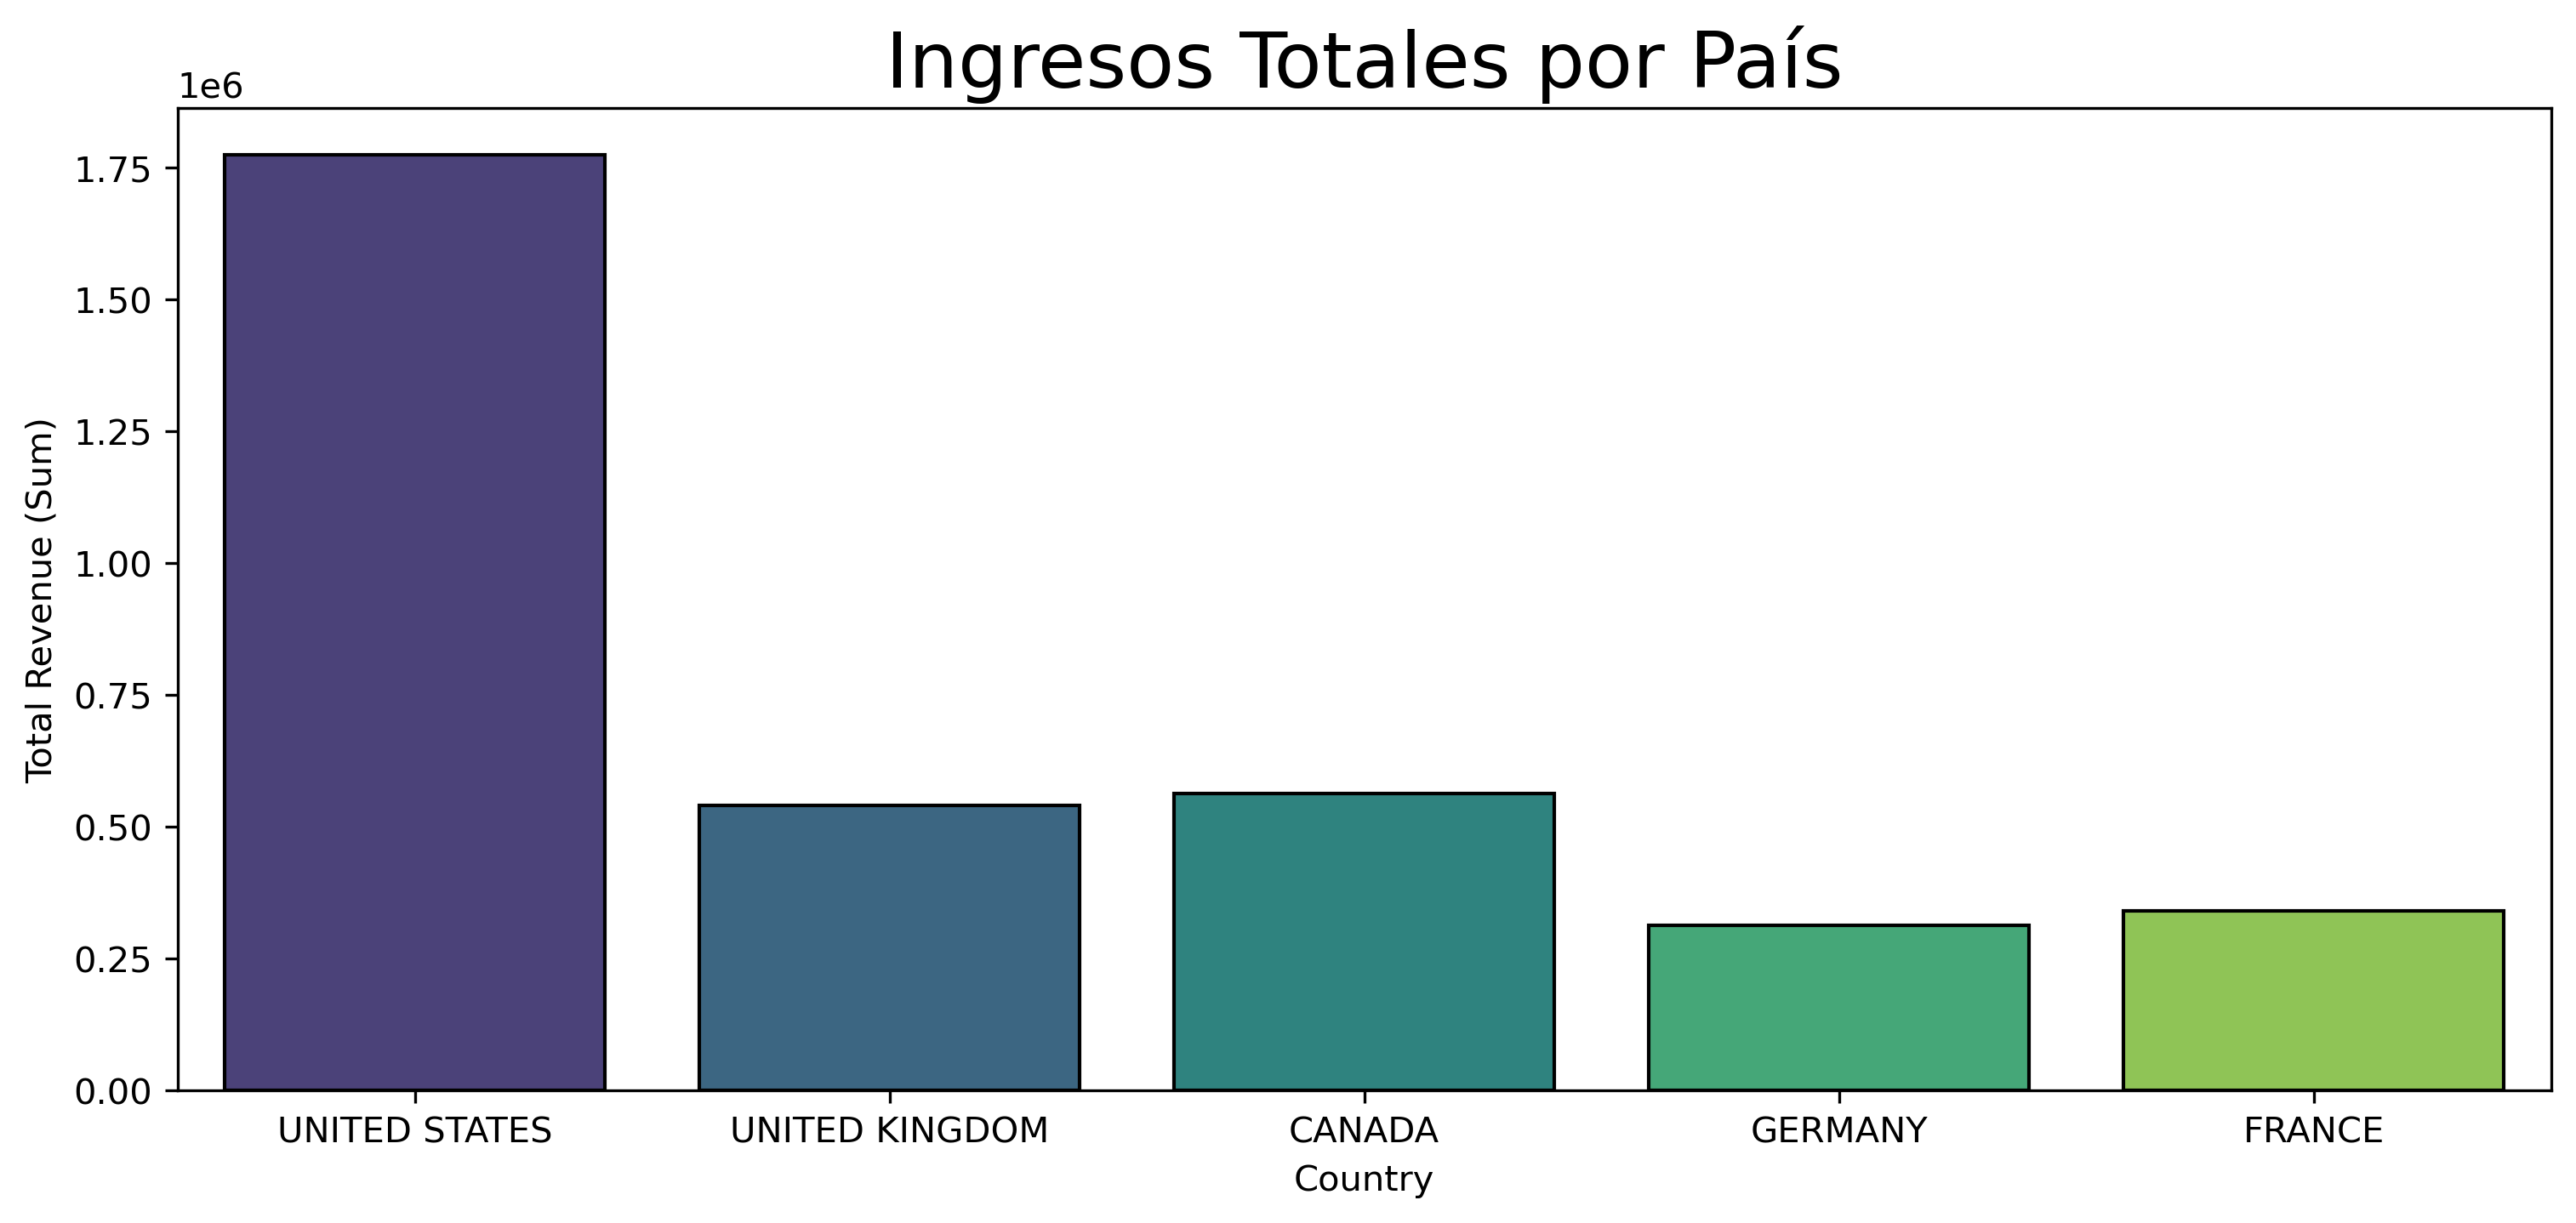

In [92]:
plt.figure(figsize=(12,5),dpi=300) #DEFINE DIMENSIONES DE LA GRÁFICA CON MATPLOTLIB
#LLAMAMOS DE LA LIBRERÍA SEABORN EL GRÁFICO DE BARPLOT.
sns.barplot(data = df_clean,                              #DATAFRAME.
            x = 'Country',                                #COLUMNA CATEGÓRICA.
            y = 'Total_Revenue',                          #COLUMNA NUMÉRICA.
            estimator = "sum",                            #ALTURA DE LA BARRA (CÁCULOS COMO: SUM, MEAN, MAX, MIN, STD, ETC.)
            palette = 'viridis',                          #PALETA DE COLORES, EXISTEN MUCHAS.
            edgecolor = "black",                          #COLOR DEL BORDE LA BARRA.
            errorbar = None)                              #ELIMINAR BARRA DE ERRORES, SON MOLESTAS A VECES, PERO SI FIJAN VALOR TRUE, PUEDEN VERLAS (MUY  COMÚN EN EXCEL)

plt.title('Ingresos Totales por País', fontsize = 22)     #DEFINIMOS TÍTULO.
plt.xlabel("Country")                                     #NOMBRE EJE HORIZONTAL.
plt.ylabel('Total Revenue (Sum)')                         #NOMBRE EJE VERTICAL
plt.show()                                                #MOSTRAR GRÁFICO. SI NO SE PONE ESTA SENTENCIA AL FINAL, EL GRÁFICO SE CREA COMO OBJETO, PERO NO SALE VISUALIZADO POR PANTALLA.

#### 🚀 __Histogram__


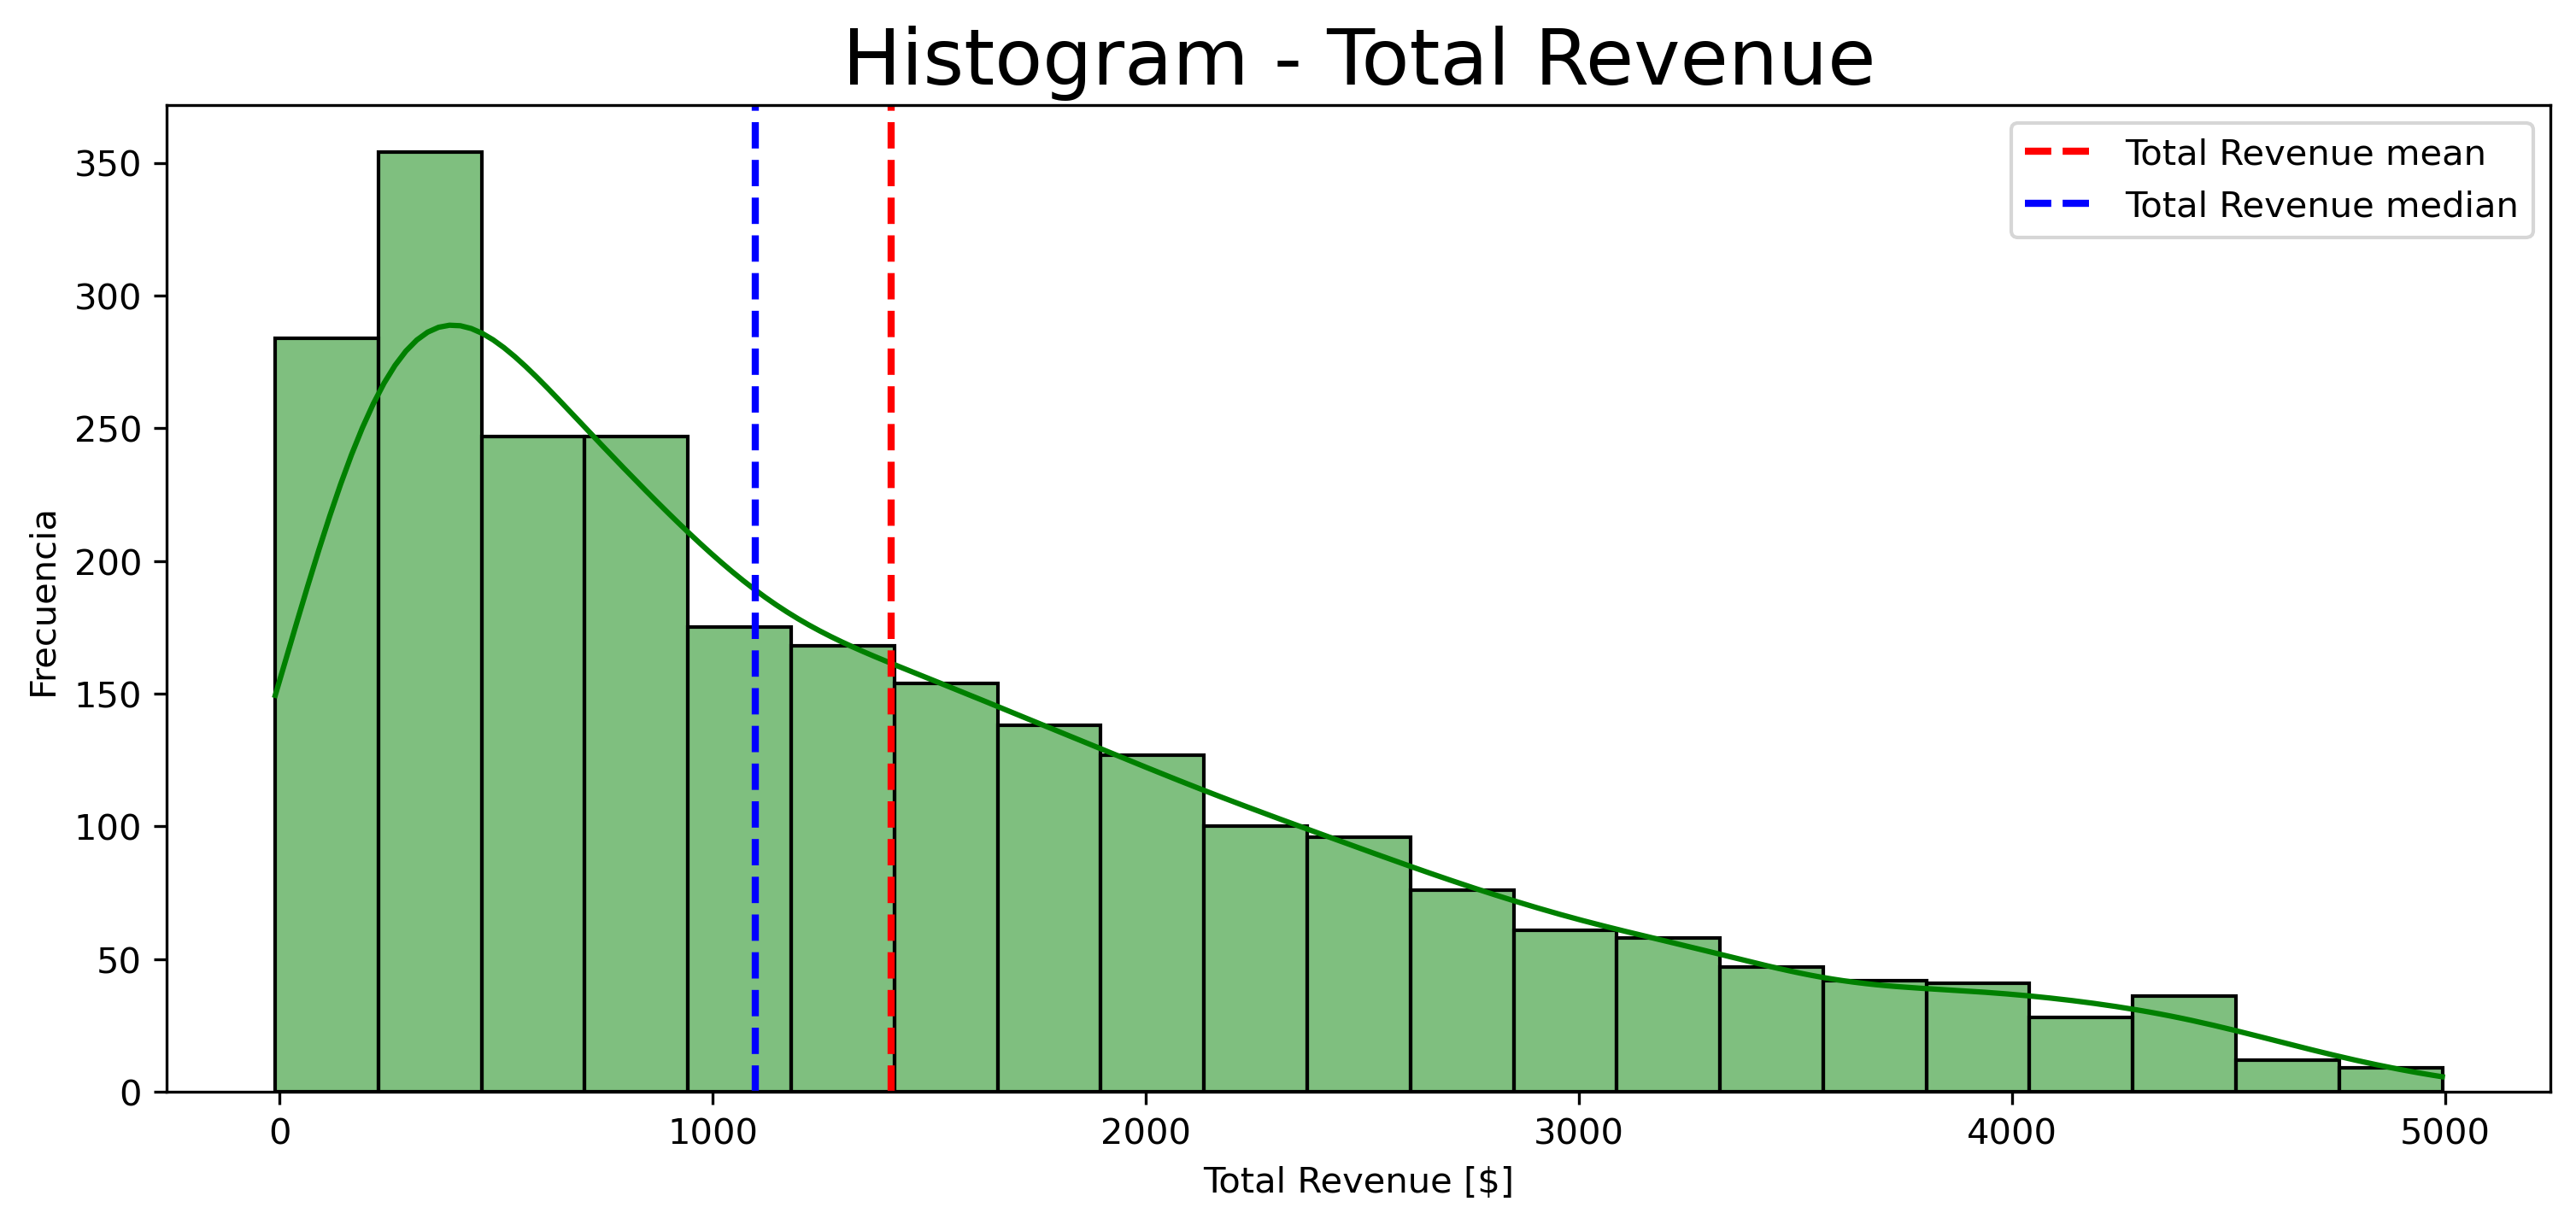

In [93]:
#CALCULEMOS LA MEDIA Y MEDIANA PARA LA VARIABLE NUMÉRICA QUE QUEREMOS GRAFICAR CON UN HISTOGRAMA. EL OBJETIVO, ES PODER INCLUIR,
#RECTAS VERTICALES QUE MUESTREN ESTOS VALORES DENTRO DEL RANGO DE LA VARIABLE.
mean   = df_clean['Total_Revenue'].mean()
median = df_clean['Total_Revenue'].median()

plt.figure(figsize=(12,5),dpi=300)

sns.histplot(data = df_clean,             #DATASET
             x = 'Total_Revenue',         #VARIABLE NUMÉRICA
             color = "green",             #COLOR BARRA
             kde= True)                   #CURVA DE DENSIDAD QUE MUESTRA EL PERFIL-FORMA DE LA DISTRIBUCIÓN CON UNA LINEA CURVA

plt.axvline(x = mean, color ='red' , linestyle ="--" , linewidth = 2, label = "Total Revenue mean" )       #LÍNEA VERTICAL MEDIA.
plt.axvline(x = median, color ='blue' , linestyle ="--" , linewidth = 2, label = "Total Revenue median" )  #LÍNEA VERTICAL MEDIANA

plt.legend() #MOSTRAR LEYENDAS DEFINIDAS EN label.
plt.title("Histogram - Total Revenue", fontsize = 22) #TÍTULO
plt.xlabel("Total Revenue [$]") #TITULO EJE X
plt.ylabel("Frecuencia") #TÍTULO EJE Y
plt.show()

#### 📦⚞ • ⚟ __Box plot__

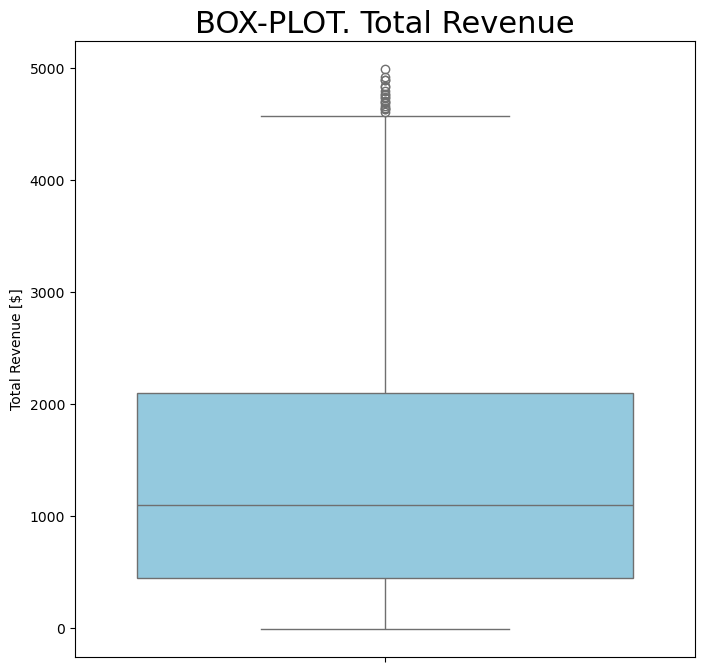

In [94]:
plt.figure(figsize = (8,8),dpi=100) #DIMENSIONES FIGURA

sns.boxplot(data  = df_clean,        #DATAFRAME
            y     = "Total_Revenue", #COLUMNA NUMÉRICA - SETEAR X=.. SI SE QUIERE HORIZONTAL
            color = "skyblue")       #COLOR - TEMA

plt.title("BOX-PLOT. Total Revenue", fontsize = 22) #TÍTULO
plt.ylabel("Total Revenue [$]") #TÍTULO EJE Y.
plt.show()

#### 🌡️ __Heat map__: Correlation Matrix - Pearson coeficient

In [95]:
corr = df_clean.corr(numeric_only=True)
corr

,Transaction_ID,Customer_Age,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
Transaction_ID,1.000000,-0.031783,-0.013755,0.013482,0.020508,0.021555,-0.024859
Customer_Age,-0.031783,1.000000,0.032862,-0.023720,0.017512,-0.833785,0.011821
Units_Sold,-0.013755,0.032862,1.000000,-0.004256,-0.001671,-0.053532,0.639262
Unit_Price,0.013482,-0.023720,-0.004256,1.000000,0.031147,-0.001817,0.170407
Shipping_Cost,0.020508,0.017512,-0.001671,0.031147,1.000000,0.002090,0.012409
Rating,0.021555,-0.833785,-0.053532,-0.001817,0.002090,1.000000,-0.031068
Total_Revenue,-0.024859,0.011821,0.639262,0.170407,0.012409,-0.031068,1.000000


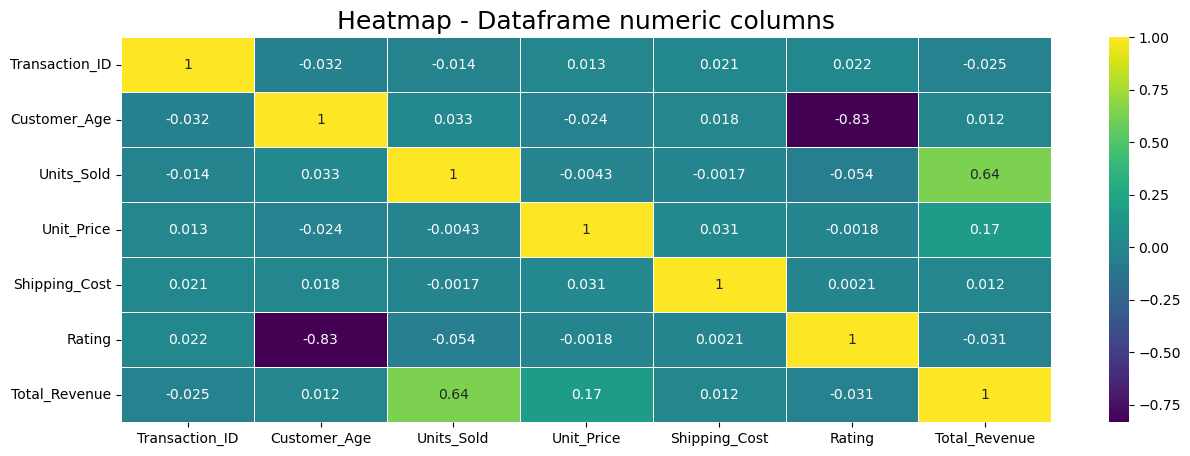

In [96]:
plt.figure(figsize=(15,5),dpi=100)
sns.heatmap(corr,
            annot=True,       # Muestra los números dentro de los cuadros
            cmap='viridis',  # Color azul (frio) para negativo, rojo (calor) para positivo
            linewidths=0.5,   # Espacio entre celdas
            linecolor='white') # Color de la línea (equivalente a edgecolor)

plt.title("Heatmap - Dataframe numeric columns", fontsize = 18) #TÍTULO
plt.show()

#### 💥 __Scatter-plot__

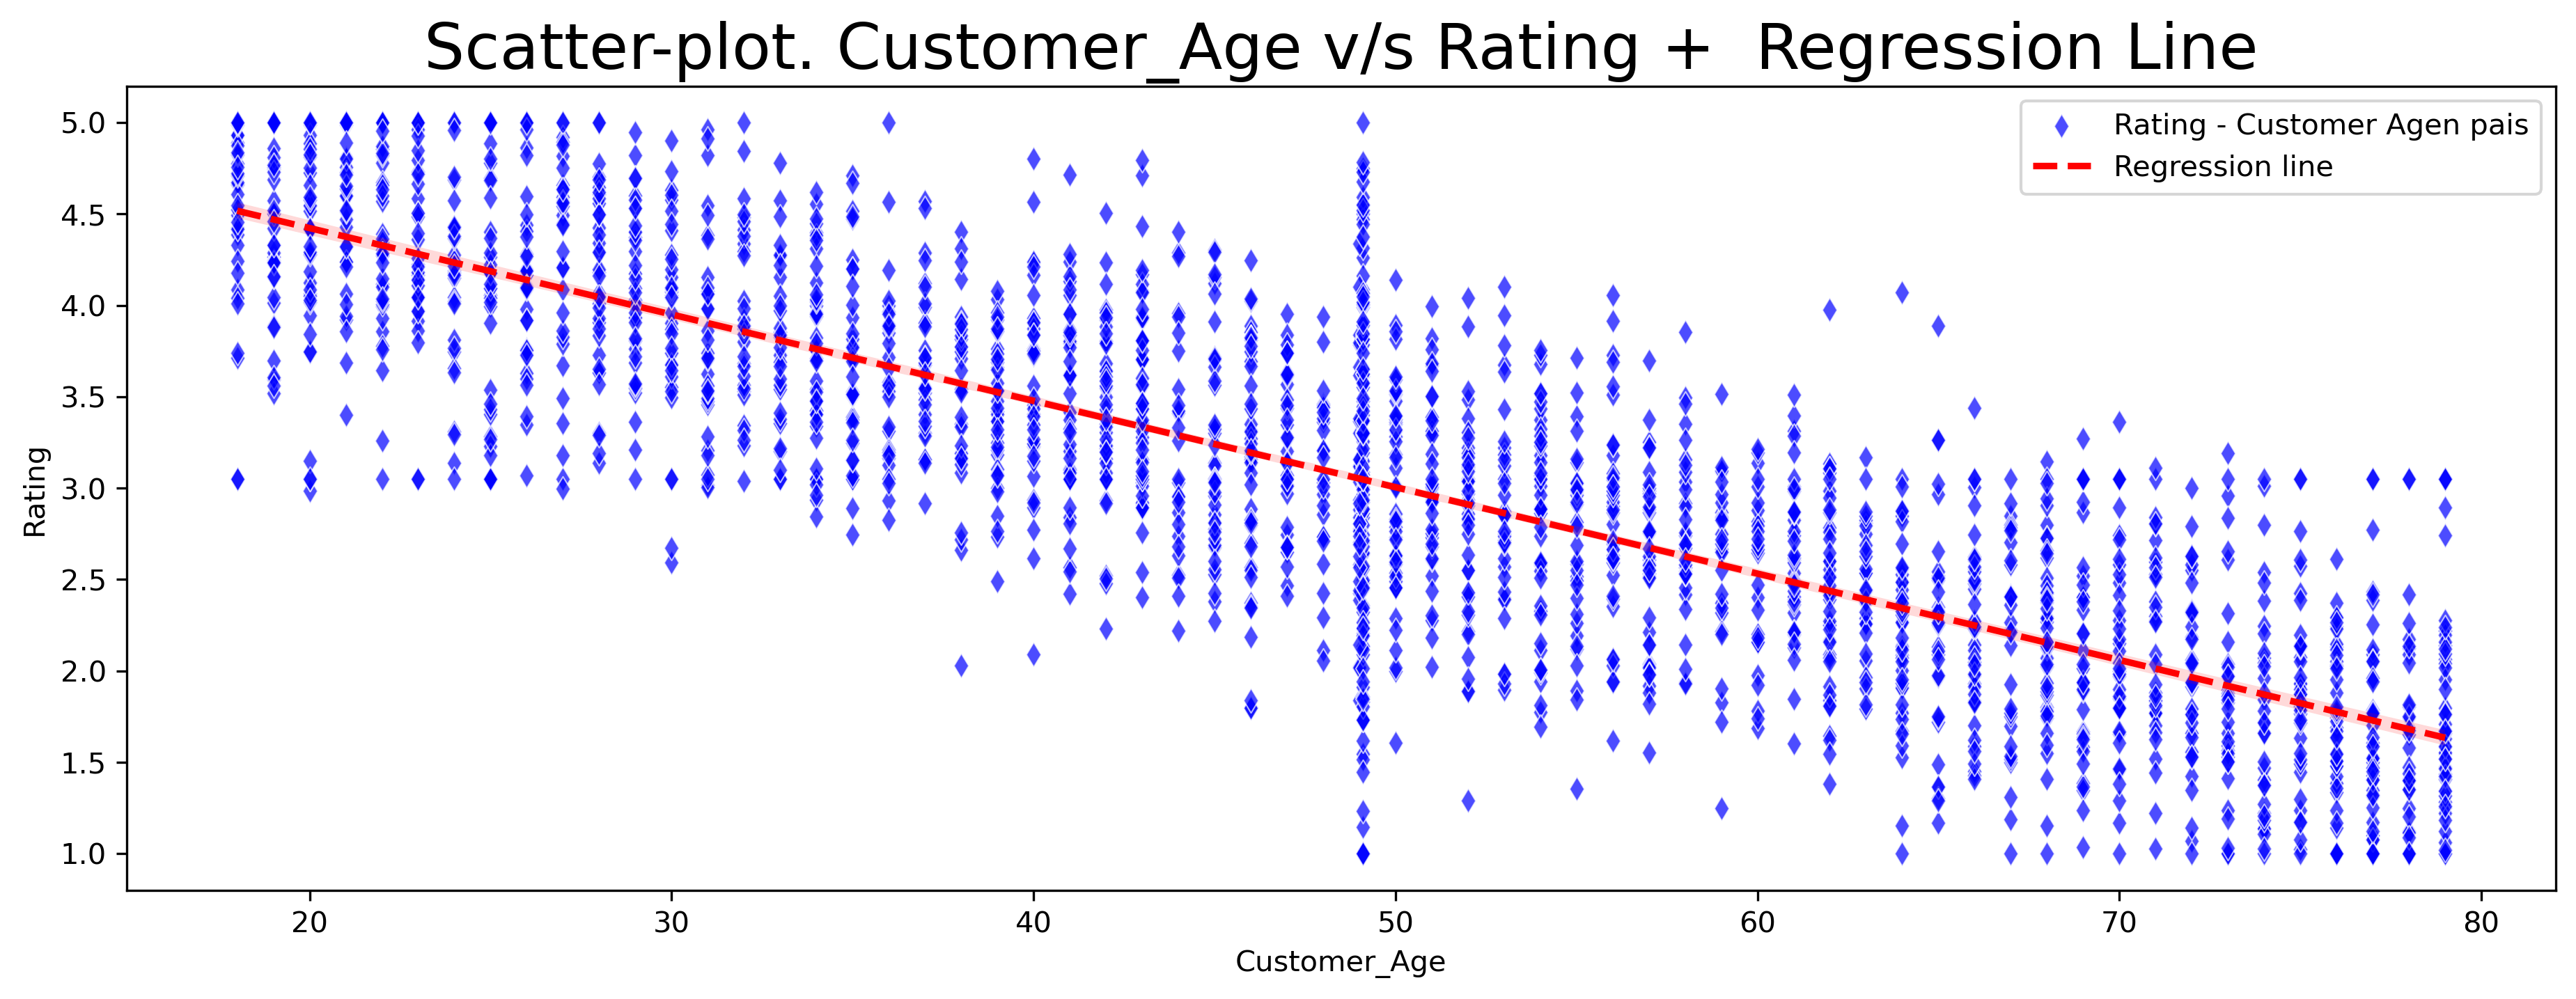

In [97]:
plt.figure(figsize = (15,5), dpi=300)

sns.scatterplot(data=df_clean,                           #DATFRAME.
                x="Customer_Age",                        #COLUMNA NUMÉRICA 1.
                y="Rating",                              #COLUMNA NUMÉRICA 2.
                color ="blue",                           #COLOR PUNTOS.
                label = "Rating - Customer Agen pais",   #ETIQUETA PARA LEYENDA.
                marker="d",                              #ESTILO DE PUNTOS.
                alpha=0.7)                               #TRANSPARENCIA.


#PLOTEAR LÍNEA DE REGRESIÓN.
sns.regplot(data=df_clean,                     #DATAFRAME.
            x="Customer_Age",                  #VARIABLE DEPENDIENTE.
            y="Rating",                        #VARIABLE INDEPENDIENTE.
            scatter=False,                     #ES INNECESARIO PLOTEAR NUEVAMENTE EL SCATTER PLOT.
            line_kws={"color": "red", "linestyle": "--"},  #CARACTERÍSTICAS DE LA LÍNEA (COLOR-ESTÍLO).
            label="Regression line")                       #ETIQUETA PARA LEYENDA.

plt.title("Scatter-plot. Customer_Age v/s Rating +  Regression Line", fontsize = 22) #TÍTUTLO
plt.legend()                                                                         #MOSTRAR LEYENDA --> NECESARIO.
plt.show()

## __Handlig Outliers__

###  🕵️‍♀️ __Detecting outliers. IQR method__

In [98]:
Q1 = df_clean['Total_Revenue'].quantile(0.25)
Q2 = df_clean['Total_Revenue'].quantile(0.50)
Q3 = df_clean['Total_Revenue'].quantile(0.75)

IQR = Q3 - Q1 

upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

In [99]:
outliers_total_revenue = df_clean[(df_clean['Total_Revenue'] < lower_limit) | (df['Total_Revenue'] > upper_limit)]
outliers_total_revenue

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
124,5124,2024-01-06 04:00:00,77.000000,HOME,UNITED STATES,10,468.936789,40.284607,1.348010,4702.831046
128,5128,2024-01-06 08:00:00,46.000000,BOOKS,UNITED STATES,10,467.598759,16.328766,2.811233,4666.204384
134,5134,2024-01-06 14:00:00,26.000000,TOYS,CANADA,10,482.908161,42.121283,4.188957,4835.583705
175,5175,2024-01-08 07:00:00,49.094884,ELECTRONICS,UNITED STATES,10,488.815350,44.867201,3.150067,4893.519344
228,5228,2024-01-10 12:00:00,47.000000,BOOKS,UNITED KINGDOM,10,464.246927,84.884453,3.151073,4641.465905
343,5343,2024-01-15 07:00:00,35.000000,BOOKS,UNITED STATES,10,464.317132,75.188607,3.527761,4633.310109
482,5482,2024-01-21 02:00:00,38.000000,HOME,UNITED STATES,10,478.113996,24.161933,3.905482,4744.066565
615,5615,2024-01-26 15:00:00,49.094884,HOME,CANADA,10,479.456005,40.464964,3.196612,4768.238221
663,5663,2024-01-28 15:00:00,53.000000,ELECTRONICS,UNITED KINGDOM,10,499.190281,82.623070,3.123166,4992.820153
894,5894,2024-02-07 06:00:00,74.000000,ELECTRONICS,UNITED STATES,10,469.769361,69.024723,1.467809,4687.229364


###  🚧 __Handling outliers. Winsorization__

Caps extreme values at a given percentile threshold. The row is kept — only the extreme value is replaced.

In [100]:
df_clean.head()

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,CLOTHING,UNITED STATES,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,CLOTHING,UNITED KINGDOM,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,HOME,UNITED STATES,1,347.837835,21.641612,3.171993,337.542782
3,5003,2024-01-01 03:00:00,32.0,CLOTHING,CANADA,8,402.287483,50.009419,4.026504,3205.648837
4,5004,2024-01-01 04:00:00,60.0,TOYS,UNITED STATES,3,108.073620,66.607272,2.194199,327.554394


Handling outliers in <code>Total_Revenue</code> using Winsorization. By defining outliers through the IQR method, we can visualize the removal of extreme data points and ensure a more robust distribution.

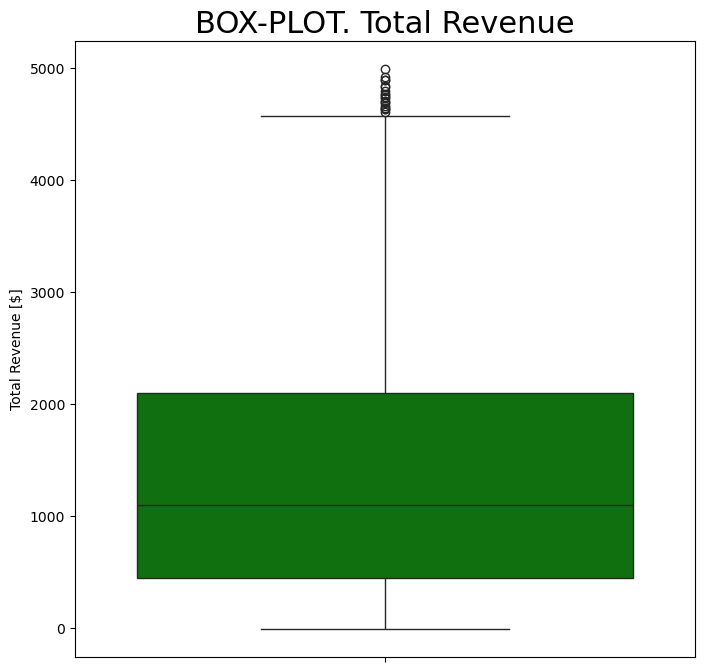

In [101]:
plt.figure(figsize = (8,8),dpi=100) #DIMENSIONES FIGURA

sns.boxplot(data  = df_clean,        #DATAFRAME
            y     = "Total_Revenue", #COLUMNA NUMÉRICA - SETEAR X=.. SI SE QUIERE HORIZONTAL
            color = "green")       #COLOR - TEMA

plt.title("BOX-PLOT. Total Revenue", fontsize = 22) #TÍTULO
plt.ylabel("Total Revenue [$]") #TÍTULO EJE Y.
plt.show()

In [102]:
#APPLYING WINSORIZATION
lower_bound = df_clean['Total_Revenue'].quantile(0.05)
upper_bound = df_clean['Total_Revenue'].quantile(0.95)

df_clean['Total_Revenue'] = df_clean['Total_Revenue'].clip(lower = lower_bound, upper = upper_bound)

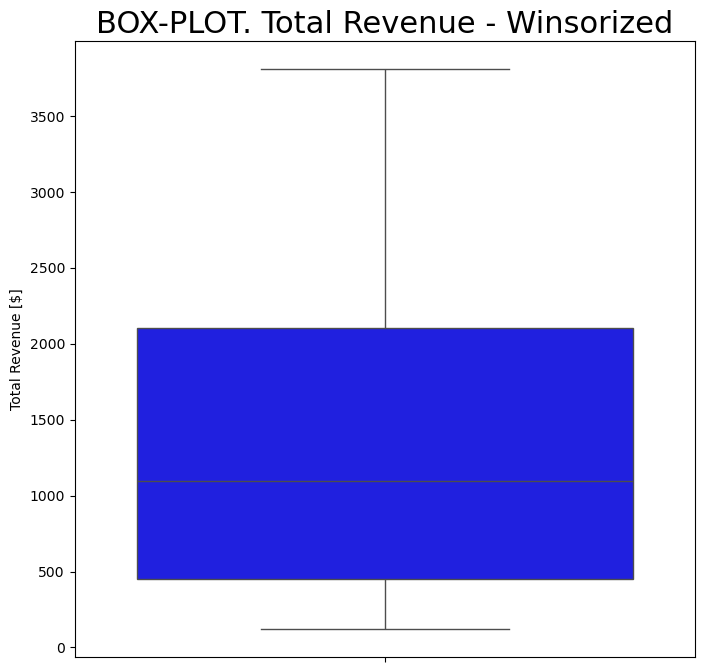

In [103]:
plt.figure(figsize = (8,8),dpi=100) #DIMENSIONES FIGURA

sns.boxplot(data  = df_clean,        #DATAFRAME
            y     = "Total_Revenue", #COLUMNA NUMÉRICA - SETEAR X=.. SI SE QUIERE HORIZONTAL
            color = "blue")       #COLOR - TEMA

plt.title("BOX-PLOT. Total Revenue - Winsorized", fontsize = 22) #TÍTULO
plt.ylabel("Total Revenue [$]") #TÍTULO EJE Y.
plt.show()

In [104]:
#CHECKING OUTLIERS
outliers_total_revenue = df_clean[(df_clean['Total_Revenue'] < lower_limit) | (df['Total_Revenue'] > upper_limit)]
outliers_total_revenue

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue


### 🏘️ __Imputation: KNN Imputer__

Fills missing values using the **K nearest neighbors** — rows that are most similar on the known features. The missing value is replaced by the average of those neighbors' values. Let's re-load our dataframe, to handle empty values in the <code>rating</code> feature.

In [105]:
#LEER DATAFRAME Y EXPLORAR PRIMEROS/ÚLTIMOS REGISTROS
path = "/content/drive/MyDrive/BI - Session 2/BI_Class_2_eda.csv" #RUTA DEL ARCHIVO, YA SEA EN SU PC O GOOGLE DRIVE (MODIFIQUE PARA SU CASO PARTICULAR)

#EN CASO DE SER INCAPAZ DE CONECTARSE DESDE GOOGLE-DRIVE, FAVOR USAR LA SIGUIENTE RUTA.
path_alternative = "https://raw.githubusercontent.com/hector1994/-IIB415A-2-2026-1-1-1500C_BUSINESS-INTELLIGENCE/refs/heads/main/BI_Class_2_eda.csv"
#df  = pd.read_csv(path)                                                        #GENERANDO DATAFRAME.
df = pd.read_csv(path_alternative)                                              #GENERANDO DATAFRAME.

In [106]:
df.isna().sum()

Transaction_ID        0
Date                  0
Customer_Age        126
Product_Category      0
Country               0
Units_Sold            0
Unit_Price            0
Shipping_Cost         0
Rating               75
Total_Revenue         0
dtype: int64

In [107]:
imputer = KNNImputer(n_neighbors=2) 

features_for_imputation = ['Rating', 'Customer_Age']
df_imputed = df_clean.copy()

df_imputed[features_for_imputation] = imputer.fit_transform(df_clean[features_for_imputation])

In [108]:
df_imputed.isna().sum()

Transaction_ID      0
Date                0
Customer_Age        0
Product_Category    0
Country             0
Units_Sold          0
Unit_Price          0
Shipping_Cost       0
Rating              0
Total_Revenue       0
dtype: int64

## ⚖️ __Scaling and encoding features__

### 📍 __Numerical handling:__ Min/Max scaling

Rescales values to the range **[0, 1]**.

$$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

We apply it to <code>Customer_Age</code>, <code>Units_Sold</code>, <code>Unit_Price</code>, <code>Shipping_Cost</code>, <code>Rating</code>, <code>Total_Revenue</code>

In [109]:
df_clean_minmax = df_clean.copy(deep = True)

In [110]:
df_clean_minmax.head()

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,CLOTHING,UNITED STATES,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,CLOTHING,UNITED KINGDOM,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,HOME,UNITED STATES,1,347.837835,21.641612,3.171993,337.542782
3,5003,2024-01-01 03:00:00,32.0,CLOTHING,CANADA,8,402.287483,50.009419,4.026504,3205.648837
4,5004,2024-01-01 04:00:00,60.0,TOYS,UNITED STATES,3,108.073620,66.607272,2.194199,327.554394


In [111]:
cols_to_normalize = ['Customer_Age', 'Units_Sold', 'Unit_Price', 'Shipping_Cost','Rating', 'Total_Revenue']
scaler = MinMaxScaler()

df_clean_minmax[['Customer_Age_norm', 'Units_Sold_norm', 'Unit_Price_norm', 'Shipping_Cost_norm','Rating_norm', 'Total_Revenue_norm']] = scaler.fit_transform(df_clean_minmax[cols_to_normalize])

print("Before and after normalization:")

df_clean_minmax[['Customer_Age','Customer_Age_norm', 
         'Units_Sold','Units_Sold_norm',
         'Unit_Price','Unit_Price_norm',
         'Shipping_Cost','Shipping_Cost_norm',
         'Rating','Rating_norm',
         'Total_Revenue','Total_Revenue_norm']].round(2)

Before and after normalization:


,Customer_Age,Customer_Age_norm,Units_Sold,Units_Sold_norm,Unit_Price,Unit_Price_norm,Shipping_Cost,Shipping_Cost_norm,Rating,Rating_norm,Total_Revenue,Total_Revenue_norm
0,56.0,0.62,9,0.89,75.03,0.01,96.28,0.96,3.51,0.63,671.61,0.15
1,69.0,0.84,2,0.11,288.10,0.02,68.67,0.67,2.87,0.47,582.70,0.13
2,46.0,0.46,1,0.00,347.84,0.03,21.64,0.17,3.17,0.54,337.54,0.06
3,32.0,0.23,8,0.78,402.29,0.03,50.01,0.47,4.03,0.76,3205.65,0.84
4,60.0,0.69,3,0.22,108.07,0.01,66.61,0.65,2.19,0.30,327.55,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,30.0,0.20,7,0.67,292.66,0.02,30.95,0.27,3.65,0.66,2087.11,0.53
2496,69.0,0.84,3,0.22,237.35,0.02,43.85,0.41,1.62,0.16,713.67,0.16
2497,43.0,0.41,3,0.22,68.17,0.01,71.43,0.70,3.47,0.62,198.04,0.02
2498,39.0,0.34,2,0.11,490.48,0.04,65.68,0.64,3.70,0.68,975.98,0.23


### 📍 __Numerical handling:__ Standarization

Rescales values so the variable has **mean = 0** and **standard deviation = 1**.

$$Z = \frac{X - \mu}{\sigma}$$

We apply it to <code>Customer_Age</code>, <code>Units_Sold</code>, <code>Unit_Price</code>, <code>Shipping_Cost</code>, <code>Rating</code>, <code>Total_Revenue</code>

In [112]:
df_std = df_clean.copy()
std_scaler = StandardScaler()

cols_to_standardize = ['Customer_Age', 'Units_Sold', 'Unit_Price', 'Shipping_Cost','Rating', 'Total_Revenue']
df_std[['Customer_Age_norm', 'Units_Sold_norm', 'Unit_Price_norm', 'Shipping_Cost_norm','Rating_norm', 'Total_Revenue_norm']] = std_scaler.fit_transform(df_std[cols_to_standardize])

print("Z-scores:")
df_std[['Customer_Age','Customer_Age_norm', 
         'Units_Sold','Units_Sold_norm',
         'Unit_Price','Unit_Price_norm',
         'Shipping_Cost','Shipping_Cost_norm',
         'Rating','Rating_norm',
         'Total_Revenue','Total_Revenue_norm']].round(2)

Z-scores:


,Customer_Age,Customer_Age_norm,Units_Sold,Units_Sold_norm,Unit_Price,Unit_Price_norm,Shipping_Cost,Shipping_Cost_norm,Rating,Rating_norm,Total_Revenue,Total_Revenue_norm
0,56.0,0.40,9,1.20,75.03,-0.34,96.28,1.59,3.51,0.47,671.61,-0.66
1,69.0,1.15,2,-1.23,288.10,-0.04,68.67,0.60,2.87,-0.19,582.70,-0.74
2,46.0,-0.17,1,-1.58,347.84,0.04,21.64,-1.10,3.17,0.12,337.54,-0.96
3,32.0,-0.98,8,0.85,402.29,0.12,50.01,-0.08,4.03,0.99,3205.65,1.66
4,60.0,0.63,3,-0.88,108.07,-0.29,66.61,0.52,2.19,-0.87,327.55,-0.97
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,30.0,-1.09,7,0.51,292.66,-0.03,30.95,-0.76,3.65,0.60,2087.11,0.63
2496,69.0,1.15,3,-0.88,237.35,-0.11,43.85,-0.30,1.62,-1.44,713.67,-0.62
2497,43.0,-0.35,3,-0.88,68.17,-0.35,71.43,0.70,3.47,0.42,198.04,-1.09
2498,39.0,-0.58,2,-1.23,490.48,0.25,65.68,0.49,3.70,0.66,975.98,-0.38


### 📍 __Categorical handling:__ One-hot encoding

Creates one binary column per category. No numeric order is implied. Drop one column (k-1) to avoid the **dummy variable trap**. We apply it to `Country` (nominal variable).

In [113]:
df_ohe = df_clean.copy()
# get_dummies applies OHE and drops one column automatically with drop_first=True
country_dummies = pd.get_dummies(df_ohe['Country'], prefix='Country', drop_first=True)
df_ohe = pd.concat([df_ohe, country_dummies], axis=1)

print("One-hot encoded city columns:")
df_ohe.head()

One-hot encoded city columns:


,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue,Country_FRANCE,Country_GERMANY,Country_UNITED KINGDOM,Country_UNITED STATES
0,5000,2024-01-01 00:00:00,56.0,CLOTHING,UNITED STATES,9,75.030719,96.281280,3.510824,671.612261,False,False,False,True
1,5001,2024-01-01 01:00:00,69.0,CLOTHING,UNITED KINGDOM,2,288.095016,68.667619,2.867071,582.704472,False,False,True,False
2,5002,2024-01-01 02:00:00,46.0,HOME,UNITED STATES,1,347.837835,21.641612,3.171993,337.542782,False,False,False,True
3,5003,2024-01-01 03:00:00,32.0,CLOTHING,CANADA,8,402.287483,50.009419,4.026504,3205.648837,False,False,False,False
4,5004,2024-01-01 04:00:00,60.0,TOYS,UNITED STATES,3,108.073620,66.607272,2.194199,327.554394,False,False,False,True


### 📍 __Categorical hadling:__ Label ecoding

Converts categorical text values to integers automatically. Order is assigned arbitrarily by the encoder — **safe only for tree-based models or ordinal data**.

We apply it to `Country` (nominal  to illustrate the risk) and compare with ordinal encoding.

In [114]:
df_enc = df_std.copy()

# Creamos el codificador
le = LabelEncoder()

# Convertimos la columna Country a números y la guardamos en 'Country_label'
df_enc['Country_label'] = le.fit_transform(df_enc['Country'])

# Mostramos cómo quedó la conversión 
print("Conversión de Country a números:")
print("----------------------------------")

# Recorremos cada ciudad y su número asignado
Country = le.classes_          # Lista de ciudades únicas
numeros  = range(len(Country)) # Números del 0 en adelante

for country, numero in zip(Country, numeros):
    print(f"{country} → {numero}")

# Mostramos las columnas relevantes del resultado
print("\nResultado:")
df_enc

Conversión de Country a números:
----------------------------------
CANADA → 0
FRANCE → 1
GERMANY → 2
UNITED KINGDOM → 3
UNITED STATES → 4

Resultado:


,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue,Customer_Age_norm,Units_Sold_norm,Unit_Price_norm,Shipping_Cost_norm,Rating_norm,Total_Revenue_norm,Country_label
0,5000,2024-01-01 00:00:00,56.0,CLOTHING,UNITED STATES,9,75.030719,96.281280,3.510824,671.612261,0.399635,1.200844,-0.340258,1.589415,0.466888,-0.658512,4
1,5001,2024-01-01 01:00:00,69.0,CLOTHING,UNITED KINGDOM,2,288.095016,68.667619,2.867071,582.704472,1.146590,-1.231703,-0.039875,0.595695,-0.185564,-0.739749,3
2,5002,2024-01-01 02:00:00,46.0,HOME,UNITED STATES,1,347.837835,21.641612,3.171993,337.542782,-0.174945,-1.579209,0.044352,-1.096608,0.123478,-0.963759,4
3,5003,2024-01-01 03:00:00,32.0,CLOTHING,CANADA,8,402.287483,50.009419,4.026504,3205.648837,-0.979358,0.853337,0.121117,-0.075749,0.989536,1.656896,0
4,5004,2024-01-01 04:00:00,60.0,TOYS,UNITED STATES,3,108.073620,66.607272,2.194199,327.554394,0.629468,-0.884196,-0.293673,0.521550,-0.867527,-0.972886,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,7495,2024-04-13 23:00:00,30.0,TOYS,UNITED STATES,7,292.660117,30.954333,3.646084,2087.105591,-1.094274,0.505831,-0.033439,-0.761476,0.603976,0.634857,4
2496,7496,2024-04-14 00:00:00,69.0,HOME,UNITED KINGDOM,3,237.351032,43.853718,1.624933,713.665382,1.146590,-0.884196,-0.111415,-0.297272,-1.444486,-0.620087,3
2497,7497,2024-04-14 01:00:00,43.0,TOYS,CANADA,3,68.167457,71.428060,3.465484,198.040106,-0.347319,-0.884196,-0.349934,0.695033,0.420935,-1.091226,0
2498,7498,2024-04-14 02:00:00,39.0,CLOTHING,UNITED KINGDOM,2,490.478431,65.678724,3.704111,975.975591,-0.577151,-1.231703,0.245451,0.488135,0.662787,-0.380408,3


### 📍 __Categorical Encoding__: Ordinal Encoding

Like label encoding, but the **analyst explicitly defines the order**. The mapping reflects real domain knowledge, not alphabetical order.

We apply it to `Nivel_Rating` (ordinal variable: Bajo < Medio < Bueno < Excelente).

In [115]:
def categorizar(rating):
    if rating >= 4: return 'Excelente'
    elif rating >= 3: return 'Bueno'
    elif rating >= 2: return 'Medio'
    else: return 'Bajo'

# 2. Aplicamos la función para crear la columna de texto
df['Nivel_Rating'] = df['Rating'].apply(categorizar)

df.head()

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue,Nivel_Rating
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261,Bueno
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472,Medio
2,5002,2024-01-01 02:00:00,46.0,Home,united states,1,347.837835,21.641612,3.171993,337.542782,Bueno
3,5003,2024-01-01 03:00:00,32.0,Clothing,Canada,8,402.287483,50.009419,4.026504,3205.648837,Excelente
4,5004,2024-01-01 04:00:00,60.0,Toys,U.S.A.,3,108.073620,66.607272,2.194199,327.554394,Medio


In [116]:
# Define the explicit order

df_ordinal_encoding = df.copy(deep = True)
rating_order = [['Bajo', 'Medio', 'Bueno', 'Excelente']]

oe = OrdinalEncoder(categories=rating_order)
df_ordinal_encoding['nivel_rating_econded'] = oe.fit_transform(df_ordinal_encoding[['Nivel_Rating']]).astype(int)

print("Ordinal encoding mapping for Nivel_Rating:")
for lvl, idx in zip(rating_order[0], range(len(rating_order[0]))):
    print(f"  {lvl} → {idx}")

print("\nResult:")
df_ordinal_encoding.head()

Ordinal encoding mapping for Nivel_Rating:
  Bajo → 0
  Medio → 1
  Bueno → 2
  Excelente → 3

Result:


,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue,Nivel_Rating,nivel_rating_econded
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261,Bueno,2
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472,Medio,1
2,5002,2024-01-01 02:00:00,46.0,Home,united states,1,347.837835,21.641612,3.171993,337.542782,Bueno,2
3,5003,2024-01-01 03:00:00,32.0,Clothing,Canada,8,402.287483,50.009419,4.026504,3205.648837,Excelente,3
4,5004,2024-01-01 04:00:00,60.0,Toys,U.S.A.,3,108.073620,66.607272,2.194199,327.554394,Medio,1
